In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

In [4]:
df = pd.read_csv("../../data/Algerian_forest_fires_cleaned_dataset.csv")

In [5]:
df.head()

,Unnamed: 0,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [6]:
df = df.drop(columns=["Unnamed: 0"])

In [7]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [8]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [10]:
df = df.drop(columns=["day", "month", "year"])

In [11]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [12]:
df["Classes"].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [13]:
df["Classes"] = np.where(df["Classes"].str.contains("not fire"), 0, 1)

In [14]:
df["Classes"].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [15]:
# defining independent features and dependent features

x = df.drop(columns=["FWI"])
y = df["FWI"]

In [16]:
x.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [17]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [18]:
# train test split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [19]:
x_train.shape, x_test.shape

((170, 11), (73, 11))

In [20]:
x_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.640179,-0.295442,-0.303129,0.682819,0.495974,0.399434,0.608042,0.474804,0.528734,0.238873
RH,-0.640179,1.000000,0.201762,0.226259,-0.640759,-0.421517,-0.253547,-0.715106,-0.373155,-0.443073,-0.394121
Ws,-0.295442,0.201762,1.000000,0.244784,-0.169620,0.009523,0.092367,-0.004035,0.040699,-0.062718,-0.182236
Rain,-0.303129,0.226259,0.244784,1.000000,-0.536790,-0.288856,-0.304328,-0.341902,-0.300998,-0.367767,-0.051964
FFMC,0.682819,-0.640759,-0.169620,-0.536790,1.000000,0.625593,0.533040,0.748574,0.613526,0.781730,0.251710
DMC,0.495974,-0.421517,0.009523,-0.288856,0.625593,1.000000,0.870419,0.692435,0.983426,0.619536,0.210853
DC,0.399434,-0.253547,0.092367,-0.304328,0.533040,0.870419,1.000000,0.524898,0.943125,0.551208,-0.056844
ISI,0.608042,-0.715106,-0.004035,-0.341902,0.748574,0.692435,0.524898,1.000000,0.652179,0.737184,0.290294
BUI,0.474804,-0.373155,0.040699,-0.300998,0.613526,0.983426,0.943125,0.652179,1.000000,0.616406,0.115434
Classes,0.528734,-0.443073,-0.062718,-0.367767,0.781730,0.619536,0.551208,0.737184,0.616406,1.000000,0.177257


<Axes: >

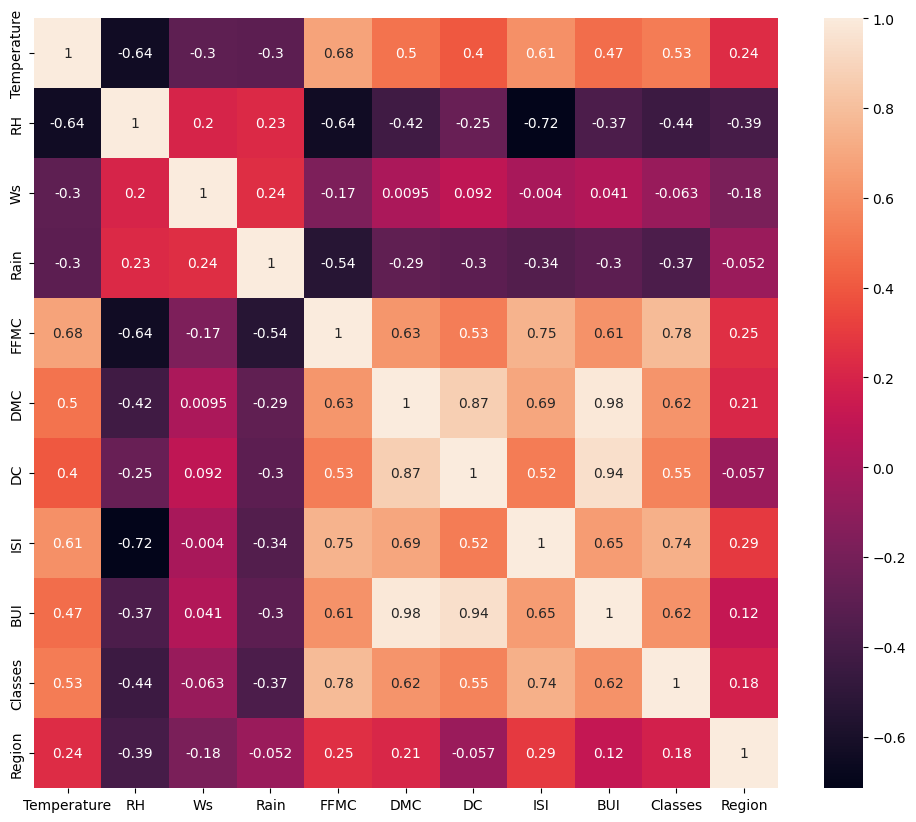

In [24]:
# checking for multicollinearity

plt.figure(figsize=(12, 10))

sns.heatmap(x_train.corr(), annot=True)

In [25]:
def correlation(dataset, threshold):

    col_corr = set()
    corr_matrix = dataset.corr()

    n = len(corr_matrix.columns)

    for i in range(n):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                col_name = corr_matrix.columns[i]
                col_corr.add(col_name)

    return col_corr

In [26]:
# threshold value comes intuitively from domain expertise

corr_features = correlation(x_train, 0.85)

In [27]:
# dropping features when correlation is more than 0.85

x_train.drop(columns=corr_features, inplace=True)
x_test.drop(columns=corr_features, inplace=True)

x_train.shape, x_test.shape

((170, 9), (73, 9))

In [28]:
# scaling or standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_before = x_train[:]
x_test_before = x_test[:]

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [29]:
x_train

array([[ 0.26131696, -0.86261203, -0.59170487, ...,  0.57277215,
         0.90992142, -1.        ],
       [-1.64645715,  1.16565969,  0.17323679, ..., -1.03570698,
        -1.098996  , -1.        ],
       [-0.0112222 , -0.5921758 , -1.73911734, ..., -0.82590535,
        -1.098996  , -1.        ],
       ...,
       [-1.91899631,  0.89522346,  0.55570761, ..., -1.05901827,
        -1.098996  , -1.        ],
       [ 0.53385612, -0.25413052,  0.17323679, ...,  0.61939473,
         0.90992142,  1.        ],
       [-0.55630052,  0.96283252,  2.08559091, ..., -0.84921665,
        -1.098996  , -1.        ]], shape=(170, 9))

In [30]:
x_test

array([[-2.83761359e-01,  8.39147711e-02, -2.09234040e-01,
        -3.85823876e-01,  6.47089705e-01, -5.89987708e-02,
         2.23102774e-01,  9.09921419e-01, -1.00000000e+00],
       [ 2.61316957e-01, -5.92175802e-01, -9.74175691e-01,
        -3.85823876e-01,  7.52243844e-01, -3.92549439e-01,
         3.86281817e-01,  9.09921419e-01, -1.00000000e+00],
       [-1.10137883e+00, -3.21739572e-01,  9.38178437e-01,
         6.21141440e-01, -9.65273758e-01, -9.12267923e-01,
        -8.25905354e-01, -1.09899600e+00,  1.00000000e+00],
       [ 5.33856115e-01, -3.21739572e-01, -9.74175691e-01,
        -2.94281575e-01,  1.42349838e-01,  2.90065882e-01,
        -6.16103728e-01, -1.09899600e+00,  1.00000000e+00],
       [-5.56300516e-01,  1.51523828e-01, -5.91704866e-01,
        -3.85823876e-01,  5.55956118e-01,  8.06270905e-02,
        -5.66327264e-02,  9.09921419e-01,  1.00000000e+00],
       [ 1.89655190e+00,  8.39147711e-02, -2.50405899e+00,
         1.63429932e-01, -2.57235889e-01, -2.529235

Text(0.5, 1.0, 'x_train after scaling')

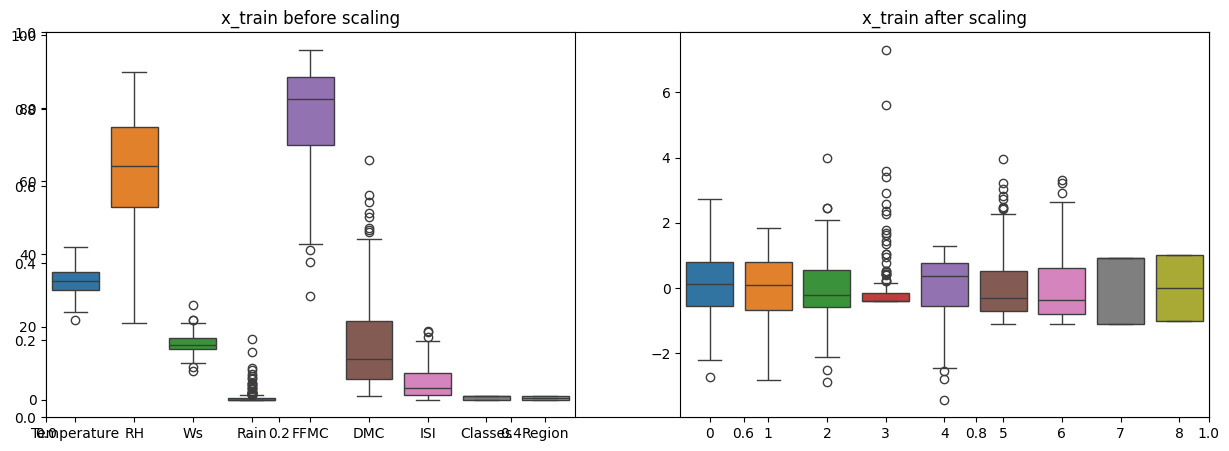

In [32]:
# box plots to visualize the affect of standard scaler

plt.subplots(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=x_train_before)
plt.title("x_train before scaling")

plt.subplot(1, 2, 2)
sns.boxplot(data=x_train)
plt.title("x_train after scaling")

Mean Absolute Error:  0.5648036371485072
R2 Score:  0.9847206874554418


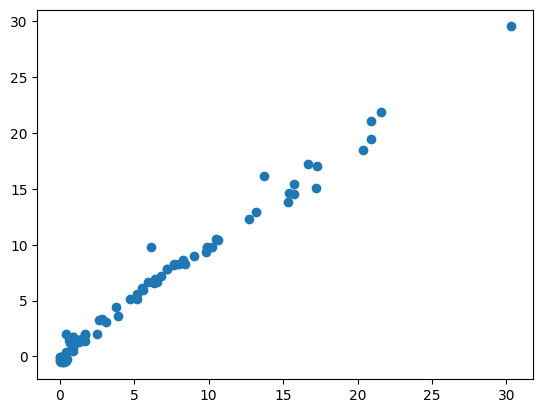

In [33]:
# Linear Regression Model

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

score = r2_score(y_test, y_pred)

print("Mean Absolute Error: ", mae)
print("R2 Score: ", score)

plt.scatter(y_test, y_pred)

Mean Absolute Error:  1.1203368882393199
R2 Score:  0.9511364350928344


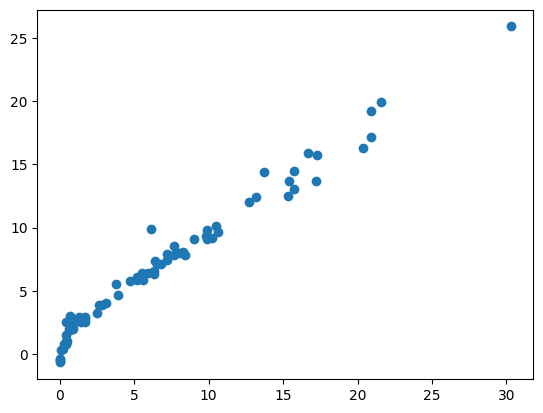

In [34]:
# Lasso Regression Model

from sklearn.linear_model import Lasso

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = Lasso()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

score = r2_score(y_test, y_pred)

print("Mean Absolute Error: ", mae)
print("R2 Score: ", score)

plt.scatter(y_test, y_pred)

In [35]:
# Cross Validation Lasso

from sklearn.linear_model import LassoCV

model = LassoCV(cv=5)

model.fit(x_train, y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [36]:
model.alpha_

np.float64(0.05761253346064308)

In [37]:
model.alphas_

array([7.1027424 , 6.62404134, 6.17760312, 5.76125335, 5.37296415,
       5.01084435, 4.67313021, 4.35817688, 4.06445034, 3.79051999,
       3.53505163, 3.29680098, 3.07460763, 2.86738937, 2.67413692,
       2.49390904, 2.32582792, 2.1690749 , 2.02288651, 1.88655073,
       1.75940353, 1.64082562, 1.53023946, 1.42710644, 1.33092425,
       1.24122441, 1.15757004, 1.07955369, 1.00679538, 0.93894074,
       0.87565928, 0.81664278, 0.76160379, 0.71027424, 0.66240413,
       0.61776031, 0.57612533, 0.53729642, 0.50108444, 0.46731302,
       0.43581769, 0.40644503, 0.379052  , 0.35350516, 0.3296801 ,
       0.30746076, 0.28673894, 0.26741369, 0.2493909 , 0.23258279,
       0.21690749, 0.20228865, 0.18865507, 0.17594035, 0.16408256,
       0.15302395, 0.14271064, 0.13309242, 0.12412244, 0.115757  ,
       0.10795537, 0.10067954, 0.09389407, 0.08756593, 0.08166428,
       0.07616038, 0.07102742, 0.06624041, 0.06177603, 0.05761253,
       0.05372964, 0.05010844, 0.0467313 , 0.04358177, 0.04064

In [38]:
model.mse_path_

array([[50.65386968, 76.54197718, 42.60540011, 85.19903601, 37.22447771],
       [44.75111814, 74.82132255, 38.341692  , 85.19903601, 33.05643554],
       [39.36934038, 67.35349762, 32.91718118, 77.16947646, 28.98441557],
       [34.66809152, 60.76849885, 28.30179163, 70.00628728, 25.07891899],
       [30.56005987, 54.39656706, 24.38332378, 63.69553448, 21.70030699],
       [26.96916466, 47.86216351, 21.06462063, 58.13161794, 18.77862509],
       [23.82945553, 42.15575307, 18.26138649, 53.22232605, 16.25301222],
       [21.08318369, 37.17090521, 15.90095328, 46.89293347, 14.07124316],
       [18.68014904, 32.81473426, 13.92043855, 41.32635877, 12.18732916],
       [16.57661964, 29.00744813, 12.26540003, 36.4658746 , 10.56155236],
       [14.73438066, 25.67846082, 10.88893934, 32.22081976,  9.15943046],
       [13.12047322, 22.76665973,  9.75047302, 28.5122238 ,  7.95103045],
       [11.70583482, 20.21881242,  8.81511714, 25.27132199,  6.9102242 ],
       [10.46524798, 17.98854548,  8.0

In [39]:


y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print("Mean Absolute Error: ", mae)
print("R2 Score: ", score)


Mean Absolute Error:  0.6279134211002095
R2 Score:  0.9824854285695882


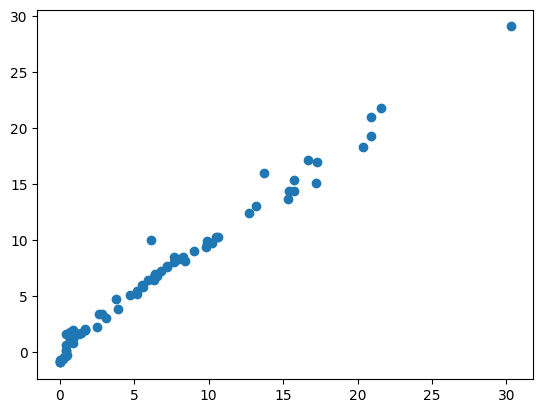

In [40]:
plt.scatter(y_test, y_pred)

Mean Absolute Error:  0.5844876727578021
R2 Score:  0.9841610358272456


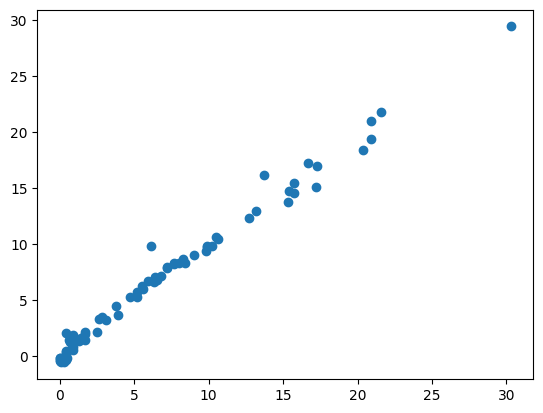

In [41]:
# Ridge Regression Model

from sklearn.linear_model import Ridge

model = Ridge()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print("Mean Absolute Error: ", mae)
print("R2 Score: ", score)

plt.scatter(y_test, y_pred)

Mean Absolute Error:  0.7943132619521893
R2 Score:  0.9762231929195331


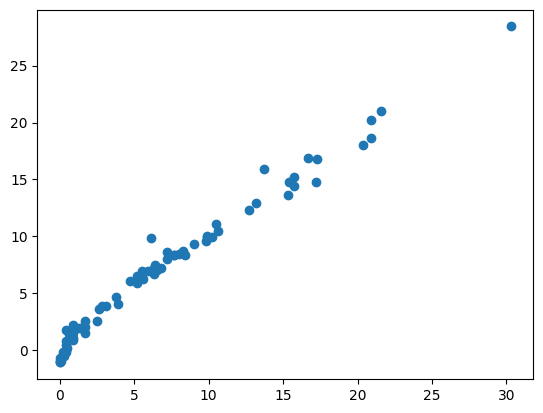

In [42]:
# RidgeCV Regression Model

from sklearn.linear_model import RidgeCV

model = RidgeCV(cv=5)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print("Mean Absolute Error: ", mae)
print("R2 Score: ", score)

plt.scatter(y_test, y_pred)

In [43]:
model.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}

Mean Absolute Error:  1.855468747971755
R2 Score:  0.8804077479376988


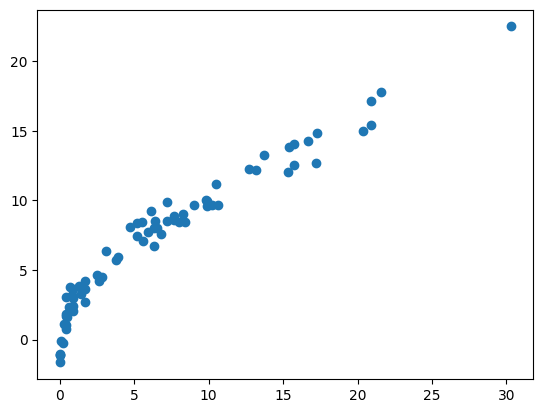

In [44]:
# ElastciNet Regression

from sklearn.linear_model import ElasticNet

model = ElasticNet()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print("Mean Absolute Error: ", mae)
print("R2 Score: ", score)

plt.scatter(y_test, y_pred)

Mean Absolute Error:  0.6856401038998695
R2 Score:  0.9807402447693788


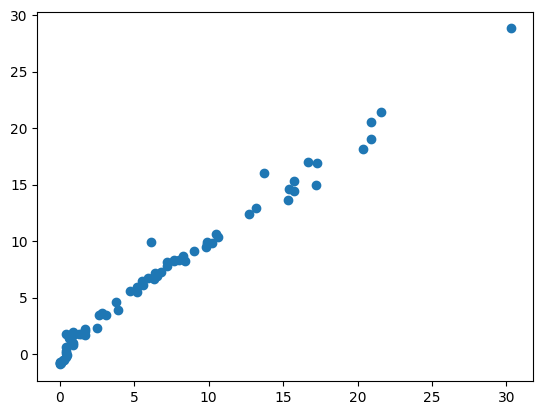

In [45]:
# ElastciNet Regression

from sklearn.linear_model import ElasticNetCV

model = ElasticNetCV(cv=5)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print("Mean Absolute Error: ", mae)
print("R2 Score: ", score)

plt.scatter(y_test, y_pred)

In [46]:
model.alphas_

array([14.20548481, 13.24808267, 12.35520624, 11.52250669, 10.74592831,
       10.0216887 ,  9.34626043,  8.71635375,  8.12890068,  7.58103998,
        7.07010326,  6.59360196,  6.14921526,  5.73477873,  5.34827384,
        4.98781808,  4.65165584,  4.3381498 ,  4.04577303,  3.77310146,
        3.51880705,  3.28165124,  3.06047893,  2.85421289,  2.66184849,
        2.48244881,  2.31514007,  2.15910738,  2.01359077,  1.87788149,
        1.75131856,  1.63328555,  1.52320757,  1.42054848,  1.32480827,
        1.23552062,  1.15225067,  1.07459283,  1.00216887,  0.93462604,
        0.87163538,  0.81289007,  0.758104  ,  0.70701033,  0.6593602 ,
        0.61492153,  0.57347787,  0.53482738,  0.49878181,  0.46516558,
        0.43381498,  0.4045773 ,  0.37731015,  0.35188071,  0.32816512,
        0.30604789,  0.28542129,  0.26618485,  0.24824488,  0.23151401,
        0.21591074,  0.20135908,  0.18778815,  0.17513186,  0.16332856,
        0.15232076,  0.14205485,  0.13248083,  0.12355206,  0.11